# Networks

### Problem 4.1. 
The time series included in DTU Learn represent the hourly capacity factor for wind power in Spain $g^{W,Spain}_t$ and Denmark $g^{W,Denmark}_t$. 
Assuming a constant electricity demand of 1 GW in every country:

a) Calculate the required wind power capacity in every country to cover, on average, the electricity
demand.

In [1]:
import pandas as pd
import numpy as np

# Load data (semicolon-separated file)
data = pd.read_csv('onshore_wind.csv', sep=';'  )
data['utc_time'] = pd.to_datetime(data['utc_time'])

# Get ESP an DNK
cf_esp = data['ESP'].to_numpy()
cf_dnk = data['DNK'].to_numpy()

# Handle missing values
data.ffill(inplace=True)

# Parameters
d = 1 # GW demand each hour in every country

# Capacities to match avg. demand
cap_esp = d / cf_esp.mean()
cap_dnk = d / cf_dnk.mean()

print(f"Capacities to meet average demand: ESP = {cap_esp:.2f} GW, DNK = {cap_dnk:.2f} GW")

# Wind generation
wind_esp = cap_esp * cf_esp
wind_dnk = cap_dnk * cf_dnk

print(f"Average wind generation: ESP = {wind_esp.mean():.2f} GW, DNK = {wind_dnk.mean():.2f} GW")

Capacities to meet average demand: ESP = 4.30 GW, DNK = 3.63 GW
Average wind generation: ESP = 1.00 GW, DNK = 1.00 GW


b) Calculate the required backup energy and backup power capacity to ensure that demand is covered
every hour, assuming the capacity found in (a).

In [2]:
# Backup power
backup_esp = np.maximum(0, d - wind_esp)
backup_dnk = np.maximum(0, d - wind_dnk)

Bpower_esp = backup_esp.max()
Benergy_esp = backup_esp.sum()
Bpower_dnk = backup_dnk.max()
Benergy_dnk = backup_dnk.sum()
print(f"Maximum backup power needed: ESP = {Bpower_esp:.2f} GW, DNK = {Bpower_dnk:.2f} GW")
print(f"Total backup energy needed: ESP = {Benergy_esp:.2f} GWh, DNK = {Benergy_dnk:.2f} GWh")

Maximum backup power needed: ESP = 0.90 GW, DNK = 0.99 GW
Total backup energy needed: ESP = 2096.68 GWh, DNK = 2954.31 GWh


c) If we assume that Spain and Denmark can be connected through an ideal interconnection (without any
losses) and the installed capacities are those calculated in section (a). Calculate the required backup
energy and backup power capacity to ensure the hourly supply of electricity demand in both countries.

In [3]:
# Backup with ideal interconnector
wind_tot = wind_esp + wind_dnk
backup_tot = np.maximum(0, 2*d - wind_tot)
Bpower_tot = backup_tot.max()
Benergy_tot = backup_tot.sum()
print(f"Maximum backup power needed with combined wind: {Bpower_tot:.2f} GW")
print(f"Total backup energy needed with combined wind: {Benergy_tot:.2f} GWh")

Maximum backup power needed with combined wind: 1.72 GW
Total backup energy needed with combined wind: 3456.69 GWh


### Problem 4.2. 
Consider the simplified network plotted in Fig. 1, which represents Denmark and its neighbouring countries. Let us assume the following convention names for the regions Germany=0, DK1=1, DK2=2, Norway=3, and Sweden=4.

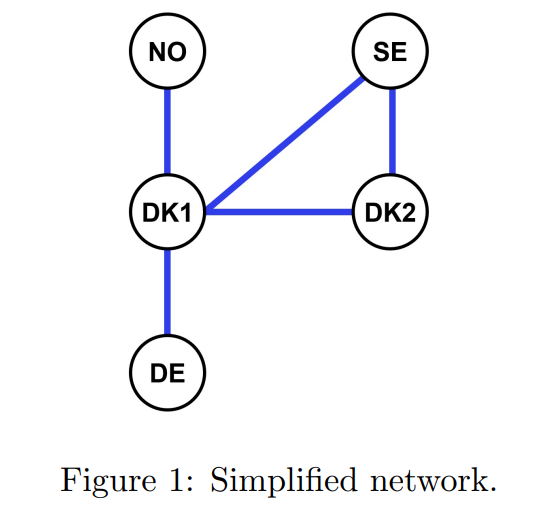

a) Create a list of the nodes and links. Sort the nodes and links in ascending order. Link (0,1) before
(1,2), before (1,3) etc.


In [11]:
# Matrices
laplacian_matrix = np.array([[1, -1, 0, 0, 0], 
                         [-1, 4, -1, -1, -1],
                         [0, -1, 2, 0, -1], 
                         [0, -1, 0, 1, 0], 
                         [0, -1, -1, 0, 2]])

degree_matrix = np.array([[1, 0, 0, 0, 0], 
                         [0, 4, 0, 0, 0],
                         [0, 0, 2, 0, 0], 
                         [0, 0, 0, 1, 0], 
                         [0, 0, 0, 0, 2]])

adjacency_matrix = degree_matrix - laplacian_matrix
print("Laplacian Matrix:\n", laplacian_matrix)
print("Degree Matrix:\n", degree_matrix)
print("Adjacency Matrix:\n", adjacency_matrix)

Laplacian Matrix:
 [[ 1 -1  0  0  0]
 [-1  4 -1 -1 -1]
 [ 0 -1  2  0 -1]
 [ 0 -1  0  1  0]
 [ 0 -1 -1  0  2]]
Degree Matrix:
 [[1 0 0 0 0]
 [0 4 0 0 0]
 [0 0 2 0 0]
 [0 0 0 1 0]
 [0 0 0 0 2]]
Adjacency Matrix:
 [[0 1 0 0 0]
 [1 0 1 1 1]
 [0 1 0 0 1]
 [0 1 0 0 0]
 [0 1 1 0 0]]


In [6]:
# List of nodes and links (DE = 0, DK1 = 1, DK2 = 2, NO = 3, SE = 4)
nodes = [0, 1, 2, 3, 4]
links = [(0, 1), (1, 2), (1, 3), (1, 4), (2, 3), (2, 4), (3, 4)]

b) Calculate the degree of each node $k_i$ and the average degree of the network 〈k〉.

In [16]:
# Calculate the degree of each node k_i
degree_nodes = np.sum(degree_matrix, axis=1)
print("Degree of each node:", degree_nodes)

degree_avg = degree_nodes.mean()
print("Average degree:", degree_avg)

Degree of each node: [1 4 2 1 2]
Average degree: 2.0


c) Create the degree matrix $D_{ij}$ . Create the adjacency matrix $A_{ij}$ and check that it is symmetric.

In [17]:
# Check if the degree matrix and the adjacency  matrix are symmetric
print("Degree matrix symmetric:", np.allclose(degree_matrix, degree_matrix.T))
print("Adjacency matrix symmetric:", np.allclose(adjacency_matrix, adjacency_matrix.T))

Degree matrix symmetric: True
Adjacency matrix symmetric: True


d) Create the incidence matrix $K_{ij}$, assuming the links are always directed from low-number node to
high-number node.


<img src="linksNnodes.png" width="300">


In [19]:
incidence_matrix = np.array([[1, 0, 0, 0, 0], 
                             [-1, 1, 1, 1, 0],
                             [0, -1, 0, 0, 1], 
                             [0, 0, -1, 0, 0], 
                             [0, 0, 0, -1, -1]])
print("Incidence Matrix:\n", incidence_matrix)

Incidence Matrix:
 [[ 1  0  0  0  0]
 [-1  1  1  1  0]
 [ 0 -1  0  0  1]
 [ 0  0 -1  0  0]
 [ 0  0  0 -1 -1]]


e) Create the Laplacian matrix $L_{ij}$ using the degree and adjacency matrices. Create the Laplacian matrix
using the incidence matrix. Check that the two definitions agree.

In [26]:
L_ij = degree_matrix - adjacency_matrix
sol_e = np.array_equal(L_ij, laplacian_matrix)

print("Laplacian matrix from degree and adjacency - does it match the original?", sol_e)

Laplacian matrix from degree and adjacency - does it match the original? True
